In [ ]:
🏦 Bank Personal Loan Modelling
📌 Objective
The goal of this project is to predict whether a customer will accept a personal loan offer.

🎯 Target Variable
Personal Loan (0 = No, 1 = Yes)
📊 Type of Problem
Supervised Learning
Classification Problem
🤖 Algorithms to be Used
Logistic Regression
Multivariate Logistic Regression
Support Vector Machine (SVM)
Decision Tree Classifier
📁 Dataset Source
Kaggle Dataset: https://www.kaggle.com/datasets/krantiswalke/bank-personal-loan-modelling

🚀 Pipeline Overview
Data Collection (Kaggle API)
Data Extraction
Data Cleaning
Exploratory Data Analysis (EDA)
Feature Engineering
Model Training
Model Evaluation
Visualization

2. Upload Kaggle API Key & Setup

In [ ]:
# Upload kaggle.json file
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
# Move kaggle.json to correct location
import os
os.makedirs('/root/.kaggle', exist_ok=True)

In [ ]:
3. Download Dataset from Kaggle

In [ ]:
# Install Kaggle (if needed)
!pip install kaggle

# Download dataset
!kaggle datasets download -d krantiswalke/bank-personal-loan-modelling

Dataset URL: https://www.kaggle.com/datasets/krantiswalke/bank-personal-loan-modelling
License(s): unknown
100% 60.6k/60.6k [00:00<00:00, 51.9MB/s]



4. Extract Dataset

In [ ]:
import zipfile

zip_path = "bank-personal-loan-modelling.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extraction Completed ✅")

Extraction Completed ✅


In [ ]:
5. Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("dataset/Bank_Personal_Loan_Modelling.csv")

# Display first 5 rows
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


6. Basic Data Inspection

In [ ]:
# Shape of dataset
df.shape

(5000, 14)

In [ ]:
# Column names
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [ ]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [ ]:
# Statistical summary
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


Data Cleaning + Preprocessing + Feature Engineering

🧹 Data Cleaning & Preprocessing
📌 Why is this important?
Raw data is rarely clean. It may contain:

Missing values
Duplicate rows
Irrelevant features
Incorrect data types
Cleaning ensures: ✔ Better model performance
✔ Faster convergence
✔ Accurate predictions

🔄 Steps We Will Perform
Remove unnecessary columns
Handle missing values
Remove duplicates
Convert data types if needed
Feature Engineering
Feature Scaling

2. Drop Unnecessary Columns

In [ ]:
# Check columns
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [ ]:
# Drop 'ID' column (not useful for prediction)
df.drop(columns=['ID'], inplace=True)

df.head()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


3. Check Missing Values

In [ ]:
# Check missing values
df.isnull().sum()

,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0
Securities Account,0


📌 Observation
If all values are 0 → No missing values
Otherwise → Handle using mean/median/mode

4. Check Duplicate Rows

In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

5. Understand Target Variable

In [ ]:
df['Personal Loan'].value_counts()

,count
Personal Loan,
0,4520
1,480


🎯 Target Variable Insight
0 → Did NOT accept loan
1 → Accepted loan
Check imbalance:

If highly imbalanced → may need techniques later


6. Feature Categorization

In [ ]:
# Separate numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
        'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
        'CD Account', 'Online', 'CreditCard'],
       dtype='object'),
 Index([], dtype='object'))

📊 Feature Types
Numerical Features
Age
Income
Experience
etc.
Categorical Features
(Mostly dataset is numeric, some are encoded already)
Note: Many categorical variables are already encoded as 0/1

7. Feature Engineering

⚙️ Feature Engineering
We improve dataset by:

Removing redundant features
Creating meaningful features
Handling correlated features

Remove Highly Correlated / Useless Features

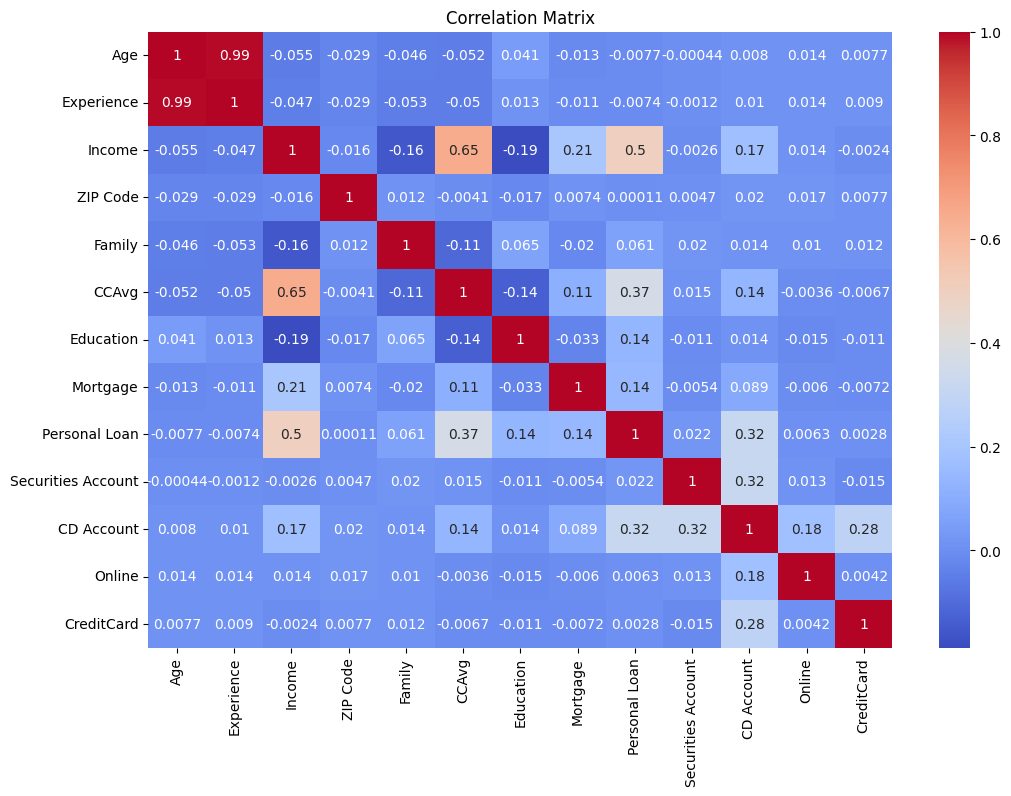

In [ ]:
# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 📌 Key Observations
- Identify highly correlated features (>0.85)
- Remove redundant ones if needed

Separate Features & Target

In [ ]:
X = df.drop('Personal Loan', axis=1)
y = df['Personal Loan']

8. Feature Scaling (Very Important for SVM & Logistic Regression)

⚖️ Feature Scaling
Why?

Algorithms like Logistic Regression & SVM depend on distance
Different scales can bias the model
We use: 👉 StandardScaler (mean = 0, std = 1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

9. Train-Test Split

✂️ Train-Test Split
We split data into:

Training Set → Model learns
Testing Set → Model evaluation
Standard split: 👉 80% Train / 20% Test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

10. Final Preprocessing Summary

✅ Completed Steps
✔ Removed unnecessary columns
✔ Checked missing values
✔ Removed duplicates
✔ Feature selection
✔ Feature scaling
✔ Train-test split

🚀 Next Step
We now begin with:

👉 Logistic Regression (Binary Classification) 👉 Model Training + Evaluation + Visualization

PART 3 — Logistic Regression (Binary Classification)


📈 Logistic Regression
📌 Definition
Logistic Regression is a classification algorithm used to predict the probability of a binary outcome (0 or 1).

Unlike Linear Regression:

Output is probability (0 to 1)
Uses Sigmoid Function (The Sigmoid Function converts the model's output into a probability (0 to 1), making it suitable for classification problems like Yes/No or Pass/Fail.)
🎯 Use Case in Our Dataset
Predict: 👉 Will customer accept loan? (1 or 0)

⚙️ Key Idea
Instead of predicting directly: We predict probability → then classify

If:

Probability ≥ 0.5 → Class = 1
Probability < 0.5 → Class = 0

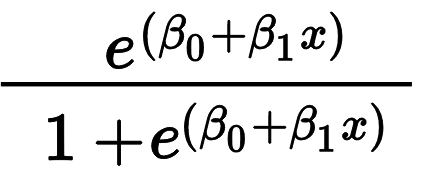


📌 Explanation
P(y=1|x) → Probability of class 1
β0 → Intercept
β1, β2... → Coefficients
x1, x2... → Features
e → Euler's number (~2.718)
🔁 Sigmoid Function Behavior
Converts any value → between 0 and 1
S-shaped curve
📉 Decision Boundary
If:

Output ≥ 0.5 → Class 1
Output < 0.5 → Class 0

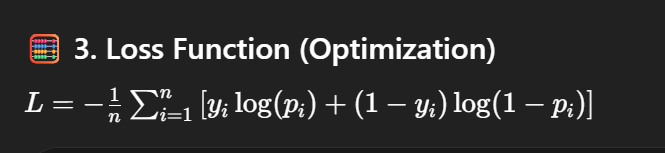

📌 Binary Cross Entropy Loss
Measures how far predictions are from actual values
Goal → Minimize loss
⚡ Optimization
Gradient Descent is used to update coefficients


4. Model Training (Code)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train, y_train)

LogisticRegression()

🔮 5. Predictions

In [ ]:
# Predictions
y_pred = log_model.predict(X_test)
'''
Predicts the final class for the test data.
Output will be 0 or 1.
0 → Customer will not accept the loan.
1 → Customer will accept the loan.
'''

# Probability predictions
y_prob = log_model.predict_proba(X_test)[:, 1]
print("Predicted Classes:\n", y_pred[:10])   # first 10 predictions
print("\nPredicted Probabilities:\n", y_prob[:10])

#predict() gives the final class (0 or 1), while predict_proba() gives the
#probability of each prediction, helping us understand how confident the model is.

Predicted Classes:
 [0 0 0 0 0 0 0 0 0 0]

Predicted Probabilities:
 [1.97238707e-04 2.62882796e-01 2.37566530e-02 1.43758210e-04
 1.79923982e-03 1.88188494e-03 3.77366054e-02 9.94079377e-03
 9.82541659e-03 6.06853638e-02]


Model Evaluation

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.955


Confusion Matrix
            Predicted No	Predicted Yes
Actual No	     900	             50
Actual Yes	   30	               20
True Positive (TP) → Correctly predicted Yes

True Negative (TN) → Correctly predicted No

False Positive (FP) → Predicted Yes but actually No

False Negative (FN) → Predicted No but actually Yes


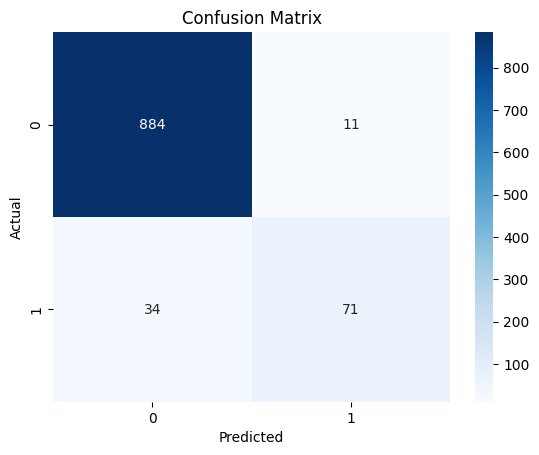

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

Compares:

y_test → Actual values
y_pred → Predicted values
It gives detailed performance metrics of the model.

It shows:

1. Precision
Out of all predicted positive results, how many were actually correct?

Example: Model predicted 10 customers will take a loan, and 8 actually took it → Precision = 80%

2. Recall
Out of all actual positive cases, how many did the model find?

Example: 10 customers actually wanted a loan, model found 9 → Recall = 90%

3. F1-Score
Combination of Precision and Recall.

It gives a balanced performance score.

4. Support
Number of actual samples belonging to each class.

Simple explanation for students:
Classification Report gives a detailed evaluation of the model by showing Precision, Recall, F1-score, and Support for each class (0 and 1).

For your bank loan project:

Class 0 → Customer did not accept loan
Class 1 → Customer accepted loan
It tells how well the model predicts both categories.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       895
           1       0.87      0.68      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.87      1000
weighted avg       0.95      0.95      0.95      1000



7. ROC Curve Visualization
ROC Curve checks how well the model separates Yes and No classes, and AUC gives the performance score of that separation.

Higher AUC means better performance.

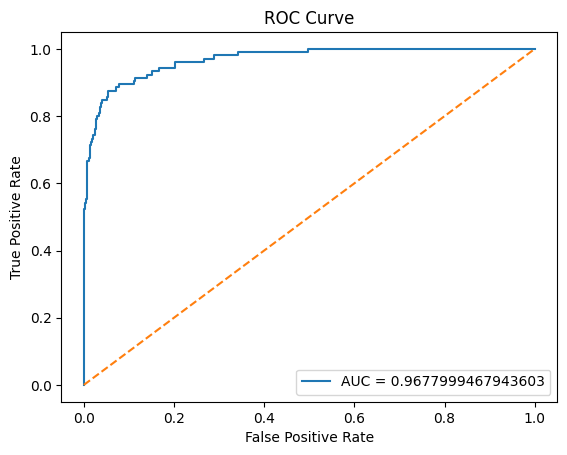

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

8. Key Insights (Markdown)

📌 Logistic Regression Insights
✅ Advantages
✔ Simple & interpretable
✔ Works well for linear decision boundaries
✔ Fast training

❌ Limitations
✖ Cannot capture complex non-linear patterns
✖ Sensitive to outliers
✖ Needs feature scaling

Algorithm	                                       Purpose
Logistic Regression	                   Baseline classification model
Multivariate Logistic Regression	   Uses multiple input features together
SVM	                           Finds the best boundary between the two classes
Decision Tree	           Makes predictions using a series of if-else decisions

PART 4 — Multivariate Logistic Regression (Deep Understanding)

1. What is Multivariate Logistic Regression?

🔁 Multivariate Logistic Regression
📌 Definition
Multivariate Logistic Regression means: 👉 Using multiple input features to predict a binary outcome.

⚠️ Important Clarification
Logistic Regression (general) = Can handle multiple features
"Multivariate" just emphasizes: ✔ More than one independent variable
🧾 Example (Our Dataset)
Instead of: Loan = f(Income)

We use: Loan = f(Age, Income, Experience, CCAvg, Mortgage, Education, etc.)

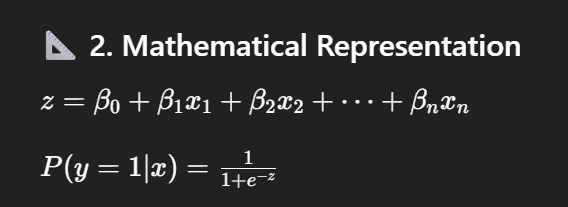

📌 Explanation
Step 1: Linear Combination z = weighted sum of features

Step 2: Apply Sigmoid Convert z → probability

First, the model combines all input features to get a value (z). Then the Sigmoid Function converts it into a probability, and the coefficients tell us whether each feature increases or decreases the chance of the positive outcome.

🔍 Interpretation of Coefficients
βi > 0 → Feature increases probability
βi < 0 → Feature decreases probability

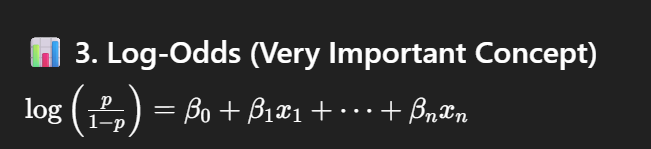

In [ ]:
# Get coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

coeff_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,Income,2.396703
6,Education,1.337324
9,CD Account,0.897669
4,Family,0.817753
1,Experience,0.405972
5,CCAvg,0.188878
7,Mortgage,0.054500
3,ZIP Code,-0.084800
8,Securities Account,-0.265740
0,Age,-0.280244


📌 Interpretation
Higher coefficient → stronger impact
Negative coefficient → reduces probability

5. Visualization of Feature Importance

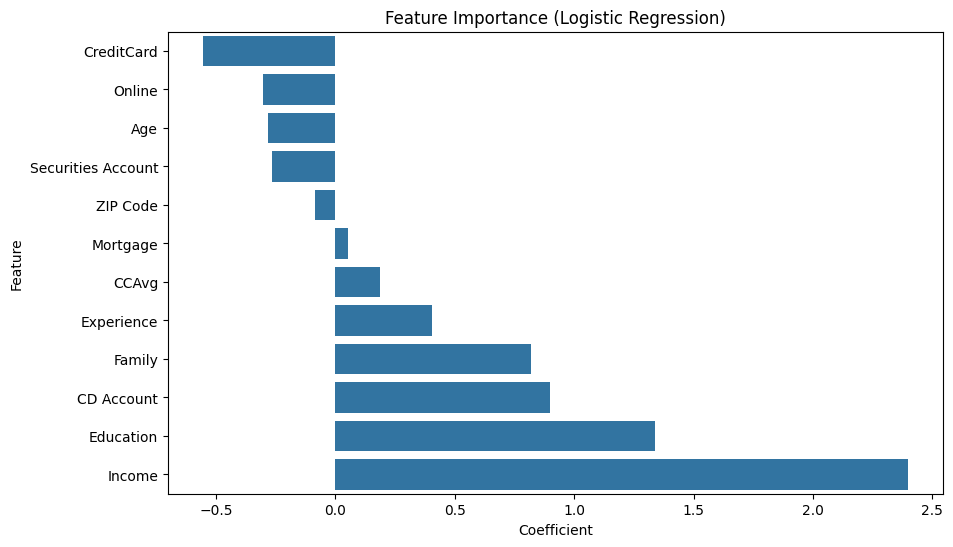

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df.sort_values(by='Coefficient'))
plt.title("Feature Importance (Logistic Regression)")
plt.show()

6. Multicollinearity Check (Advanced but Important)

⚠️ Multicollinearity
When features are highly correlated: 👉 Model becomes unstable 👉 Coefficients become unreliable

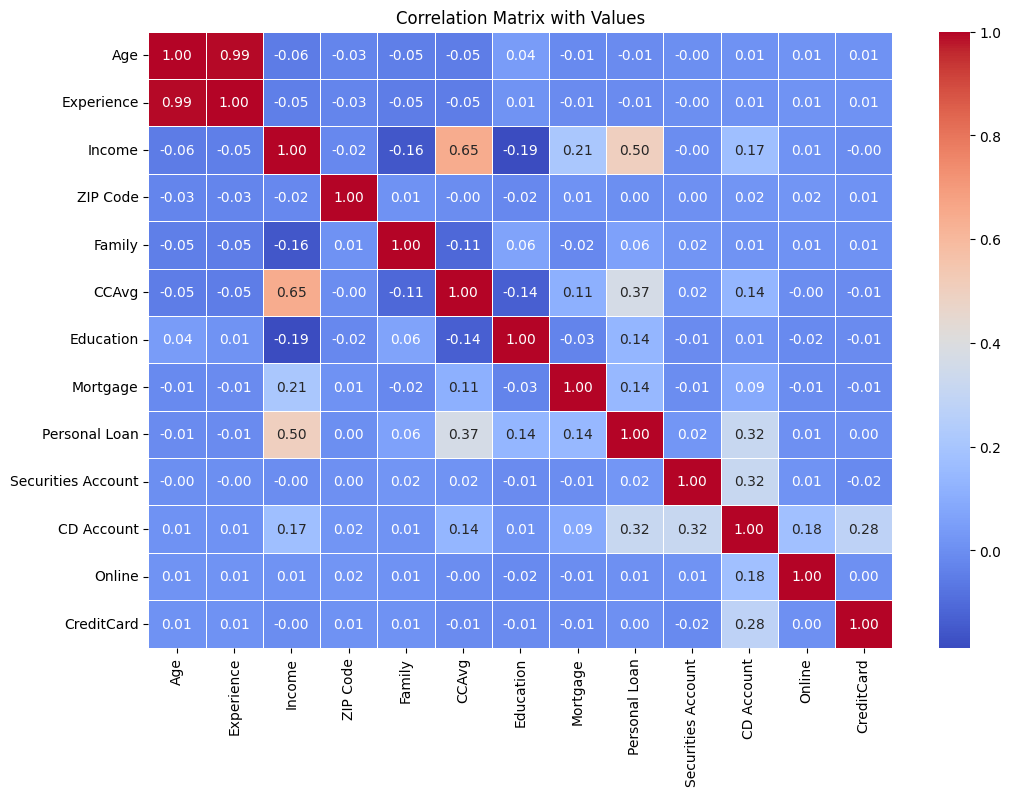

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,        # 👉 shows numbers
    fmt=".2f",         # 👉 2 decimal places
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix with Values")
plt.show()

In [ ]:
7. Regularization (Avoid Overfitting)

🔧 Regularization
We control model complexity using:

L1 Regularization (Lasso)
Can shrink coefficients to 0 → Feature selection
L2 Regularization (Ridge)
Reduces magnitude of coefficients
Cost Function with Regularization
Loss + Penalty Term

Regularization → Prevents overfitting.

L1 (Lasso) → Removes less important features (coefficient becomes 0).

L2 (Ridge) → Reduces coefficient values but keeps all features.

Cost Function → Loss + Penalty, helping the model make better predictions without becoming too complex.

In [ ]:
# L2 Regularization (default)
log_model_l2 = LogisticRegression(penalty='l2')
log_model_l2.fit(X_train, y_train)

# L1 Regularization
log_model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
log_model_l1.fit(X_train, y_train)

LogisticRegression(penalty='l1', solver='liblinear')

8. Compare Regularized Models

In [ ]:
from sklearn.metrics import accuracy_score

print("L2 Accuracy:", accuracy_score(y_test, log_model_l2.predict(X_test)))
print("L1 Accuracy:", accuracy_score(y_test, log_model_l1.predict(X_test)))

L2 Accuracy: 0.955
L1 Accuracy: 0.955


Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Predictions (already done, but safe to include)
y_pred_multi = log_model.predict(X_test)

# Classification Report
print("Classification Report (Multivariate Logistic Regression):\n")
print(classification_report(y_test, y_pred_multi))

Classification Report (Multivariate Logistic Regression):

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       895
           1       0.87      0.68      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.87      1000
weighted avg       0.95      0.95      0.95      1000



Create a Sample Test Case

In [ ]:
# Check feature order
X.columns

Index(['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities Account', 'CD Account', 'Online',
       'CreditCard'],
      dtype='object')

In [ ]:
# Example: [Age, Experience, Income, ZIP Code, Family, CCAvg, Education, Mortgage, Securities Account, CD Account, Online, CreditCard]

sample = [[45, 20, 60, 400001, 2, 1.5, 2, 0, 1, 0, 1, 0]]

In [ ]:
sample_scaled = scaler.transform(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = log_model.predict(sample_scaled)
probability = log_model.predict_proba(sample_scaled)[0][1]

print("Predicted Class:", prediction[0])
print("Probability of Loan Acceptance:", probability)

Predicted Class: 0
Probability of Loan Acceptance: 8.321721118418785e-09


In [ ]:
if prediction[0] == 1:
    print(f"Customer is LIKELY to accept the loan (Confidence: {probability:.2f})")
else:
    print(f"Customer is NOT likely to accept the loan (Confidence: {1 - probability:.2f})")

Customer is NOT likely to accept the loan (Confidence: 1.00)


In [ ]:
# Take user input
age = float(input("Enter Age: "))
experience = float(input("Enter Experience: "))
income = float(input("Enter Income: "))
zip_code = float(input("Enter ZIP Code: "))
family = float(input("Enter Family size: "))
ccavg = float(input("Enter CCAvg: "))
education = float(input("Enter Education (1/2/3): "))
mortgage = float(input("Enter Mortgage: "))
securities = float(input("Securities Account (0/1): "))
cd = float(input("CD Account (0/1): "))
online = float(input("Online (0/1): "))
credit = float(input("Credit Card (0/1): "))

user_input = [[age, experience, income, zip_code, family, ccavg,
               education, mortgage, securities, cd, online, credit]]

# Scale
user_scaled = scaler.transform(user_input)

# Predict
pred = log_model.predict(user_scaled)
prob = log_model.predict_proba(user_scaled)[0][1]

print("\nPrediction:", pred[0])
print("Probability:", prob)

if prediction[0] == 1:
    print(f"✅ Customer is LIKELY to take the loan (Confidence: {probability:.2f})")
else:
    print(f"❌ Customer is NOT likely to take the loan (Confidence: {1 - probability:.2f})")

Enter Age: 30
Enter Experience: 10
Enter Income: 150000
Enter ZIP Code: 411041
Enter Family size: 4
Enter CCAvg: 5
Enter Education (1/2/3): 3
Enter Mortgage: 7
Securities Account (0/1): 1
CD Account (0/1): 1
Online (0/1): 1
Credit Card (0/1): 0

Prediction: 1
Probability: 1.0
❌ Customer is NOT likely to take the loan (Confidence: 1.00)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


⚡ Support Vector Machine (SVM)
📌 Definition
SVM is a supervised learning algorithm used for:

Classification
Regression
🎯 Goal
👉 Find the best boundary (hyperplane) that separates classes

💡 Key Idea
Not just any boundary… 👉 Choose the one with maximum margin

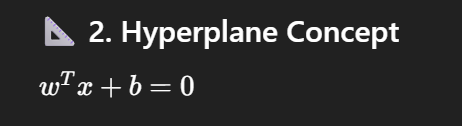

📌 Explanation
w → weight vector
x → feature vector
b → bias
🧠 In Simple Terms
👉 This equation represents a line (2D) / plane (3D) / hyperplane (higher dimensions) that separates classes

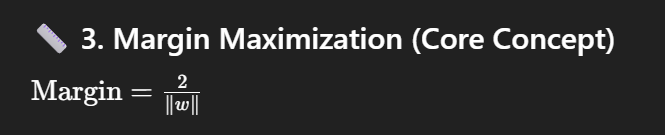

📌 Margin
Distance between hyperplane and closest data points
SVM tries to maximize this margin
⭐ Support Vectors
👉 Points closest to boundary
👉 These define the hyperplane
👉 Removing them changes model completely

4. Hard Margin vs Soft Margin

⚠️ Types of SVM
Hard Margin
No misclassification allowed
Works only for perfectly separable data
Soft Margin
Allows some errors
Controlled by parameter C
🎯 C Parameter
Large C → Less error, more overfitting
Small C → More error, better generalization


5. Kernel Trick (VERY IMPORTANT)

🔄 Kernel Trick
📌 Problem
Data is often NOT linearly separable

💡 Solution
Transform data to higher dimension

🎯 Common Kernels
Linear
Polynomial
RBF (Radial Basis Function) ⭐ most used

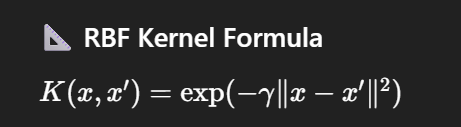

📌 Explanation
γ (gamma) controls influence of points
High gamma → overfitting
Low gamma → underfitting

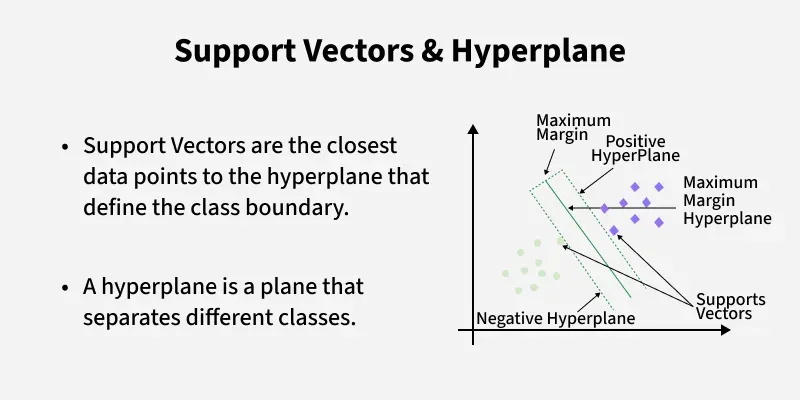

6. Train SVM Model

In [6]:
from google.colab import files

uploaded = files.upload()

Saving rainfall.csv to rainfall.csv


In [7]:
print(uploaded.keys())

dict_keys(['rainfall.csv'])


In [8]:
df = pd.read_csv("rainfall.csv")

In [11]:
print(df.columns.tolist())

[' Area', 'Year', 'average_rain_fall_mm_per_year']


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load dataset
df = pd.read_csv("rainfall.csv")

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert rainfall to numeric
df["average_rain_fall_mm_per_year"] = pd.to_numeric(
    df["average_rain_fall_mm_per_year"],
    errors="coerce"
)

# Remove rows with missing values
df = df.dropna()

# Create target column
# High rainfall = 1
# Low rainfall = 0
df["rainfall_category"] = (
    df["average_rain_fall_mm_per_year"] > 1000
).astype(int)

# Features
X = df[["Year", "average_rain_fall_mm_per_year"]]

# Target
y = df["rainfall_category"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create SVM model
svm_linear = SVC(
    kernel="linear",
    probability=True
)

# Train model
svm_linear.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


RBF Kernel SVM (Most Important)

In [13]:
svm_rbf = SVC(kernel='rbf', probability=True)

svm_rbf.fit(X_train, y_train)

SVC(probability=True)

#7. Predictions


In [14]:
y_pred_svm = svm_rbf.predict(X_test)
y_prob_svm = svm_rbf.predict_proba(X_test)[:,1]

8. Evaluation

In [15]:
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 1.0


9. Confusion Matrix

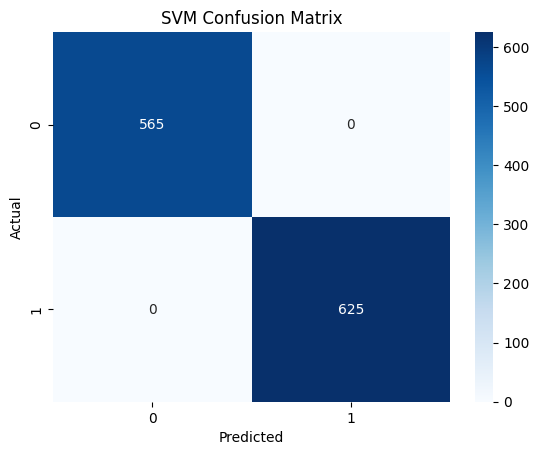

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Make predictions using the trained SVM model
y_pred_svm = svm_linear.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      1.00      1.00       625

    accuracy                           1.00      1190
   macro avg       1.00      1.00      1.00      1190
weighted avg       1.00      1.00      1.00      1190



9. ROC Curve

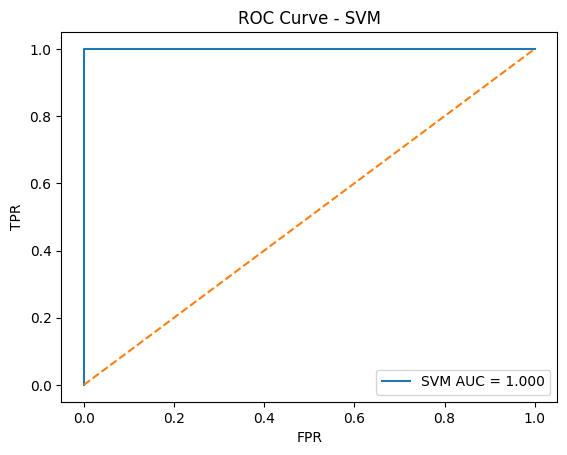

In [19]:
from sklearn.metrics import roc_curve, auc

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {auc_svm:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

10. SVM Visualization (IMPORTANT)

PCA Projection

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("rainfall.csv")

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert numerical columns to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["average_rain_fall_mm_per_year"] = pd.to_numeric(
    df["average_rain_fall_mm_per_year"],
    errors="coerce"
)

# Remove missing values
df = df.dropna()

# Select numerical features
X = df[["Year", "average_rain_fall_mm_per_year"]]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA result:")
print(X_pca)

print("\nShape of PCA data:")
print(X_pca.shape)

PCA result:
[[-0.49738927 -1.93238272]
 [-0.4231565  -1.85814995]
 [-0.34892373 -1.78391718]
 ...
 [ 1.43278915  0.59140505]
 [ 1.50702192  0.66563782]
 [ 1.58125469  0.73987059]]

Shape of PCA data:
(5947, 2)


Decision Boundary Visualization

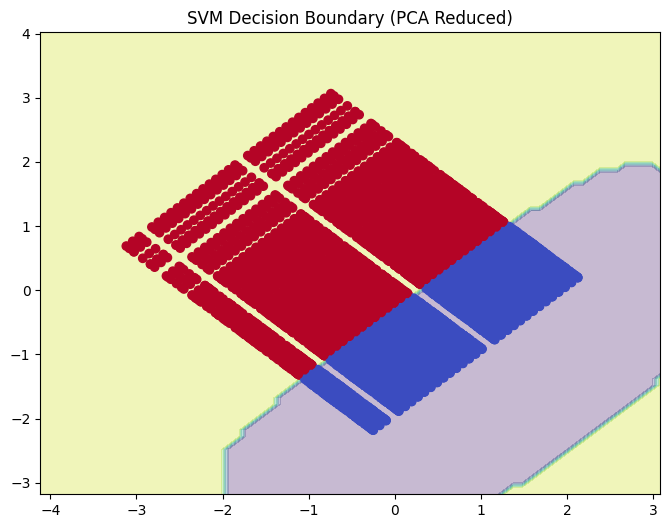

In [23]:
# Train SVM on PCA data
svm_vis = SVC(kernel='rbf')
svm_vis.fit(X_pca, y)

# Meshgrid
import numpy as np

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')
plt.title("SVM Decision Boundary (PCA Reduced)")
plt.show()

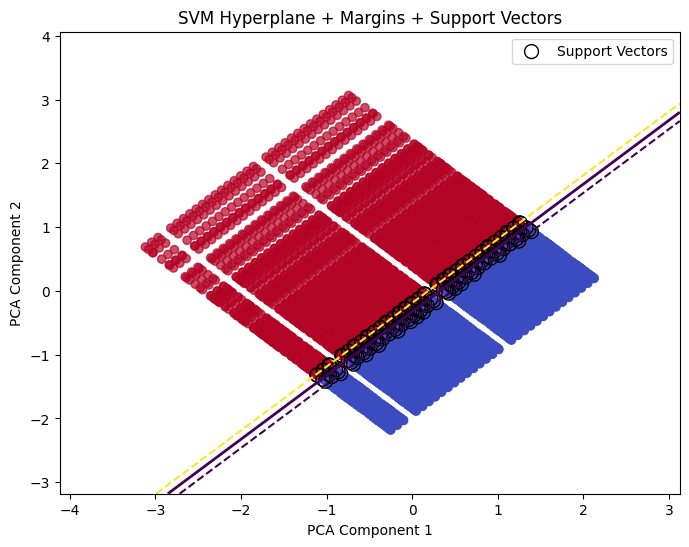

In [24]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Use LINEAR kernel to visualize hyperplane
svm_vis = SVC(kernel='linear')
svm_vis.fit(X_pca, y)

# Meshgrid
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Decision function
Z = svm_vis.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))

# Decision boundary (hyperplane)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Margins
plt.contour(xx, yy, Z, levels=[-1, 1], linestyles='dashed')

# Scatter points
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)

# Highlight support vectors
plt.scatter(
    svm_vis.support_vectors_[:,0],
    svm_vis.support_vectors_[:,1],
    s=100,
    facecolors='none',
    edgecolors='k',
    label='Support Vectors'
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SVM Hyperplane + Margins + Support Vectors")
plt.legend()
plt.show()

11. Key Insights

✅ SVM Summary
✔ Works well for high-dimensional data
✔ Effective for complex boundaries
✔ Uses support vectors only

❌ Limitations
✖ Slow on large datasets
✖ Hard to interpret
✖ Sensitive to parameter tuning

🎯 When to Use?
Medium-sized datasets
Complex boundaries
High-dimensional data

PART 6 — Decision Tree (Full Depth + Visualization)

🌳 Decision Tree
📌 Definition
A Decision Tree is a supervised learning algorithm used for:

Classification
Regression
🎯 Idea
👉 Split data into smaller groups based on conditions

It works like a flowchart:

    Root
   /    \
Condition Condition /
Yes No

💡 Example
If Income > 50 → likely to take loan
Else → not likely

Structure of Decision Tree

# 🌲 Components

## 1. Root Node
- Starting point

## 2. Decision Node
- Condition (e.g., Income > 50)

## 3. Leaf Node
- Final output (0 or 1)

## 4. Branch
- Outcome of a condition

Splitting Criteria (Very Important)

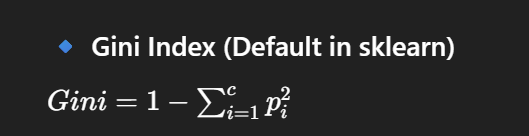

📌 Interpretation
0 → Pure node
Higher → Mixed classes
Goal: 👉 Minimize Gini

Entropy (Information Gain)

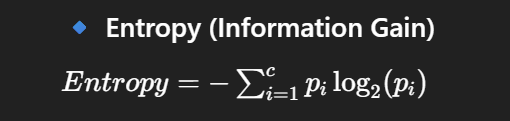

📌 Interpretation
0 → Pure
Higher → More disorder
🎯 Information Gain
Gain = Parent Entropy - Child Entropy

👉 Choose split with maximum gain

#4. Train Decision Tree Model

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

5. Predictions

In [26]:
y_pred_dt = dt_model.predict(X_test)

6. Evaluation

In [27]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


#Confusion Matrix


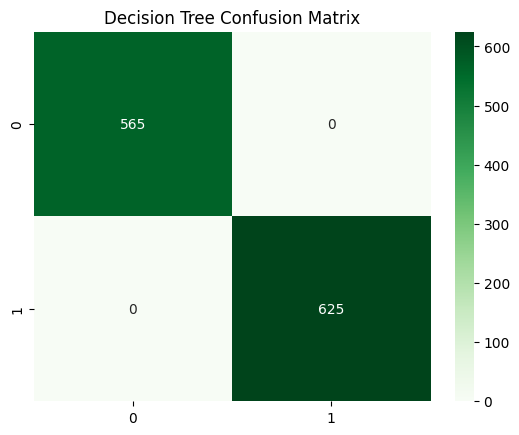

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

Classification Report

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      1.00      1.00       625

    accuracy                           1.00      1190
   macro avg       1.00      1.00      1.00      1190
weighted avg       1.00      1.00      1.00      1190



7. Tree Visualization (VERY IMPORTANT)

Simple Plot (sklearn)

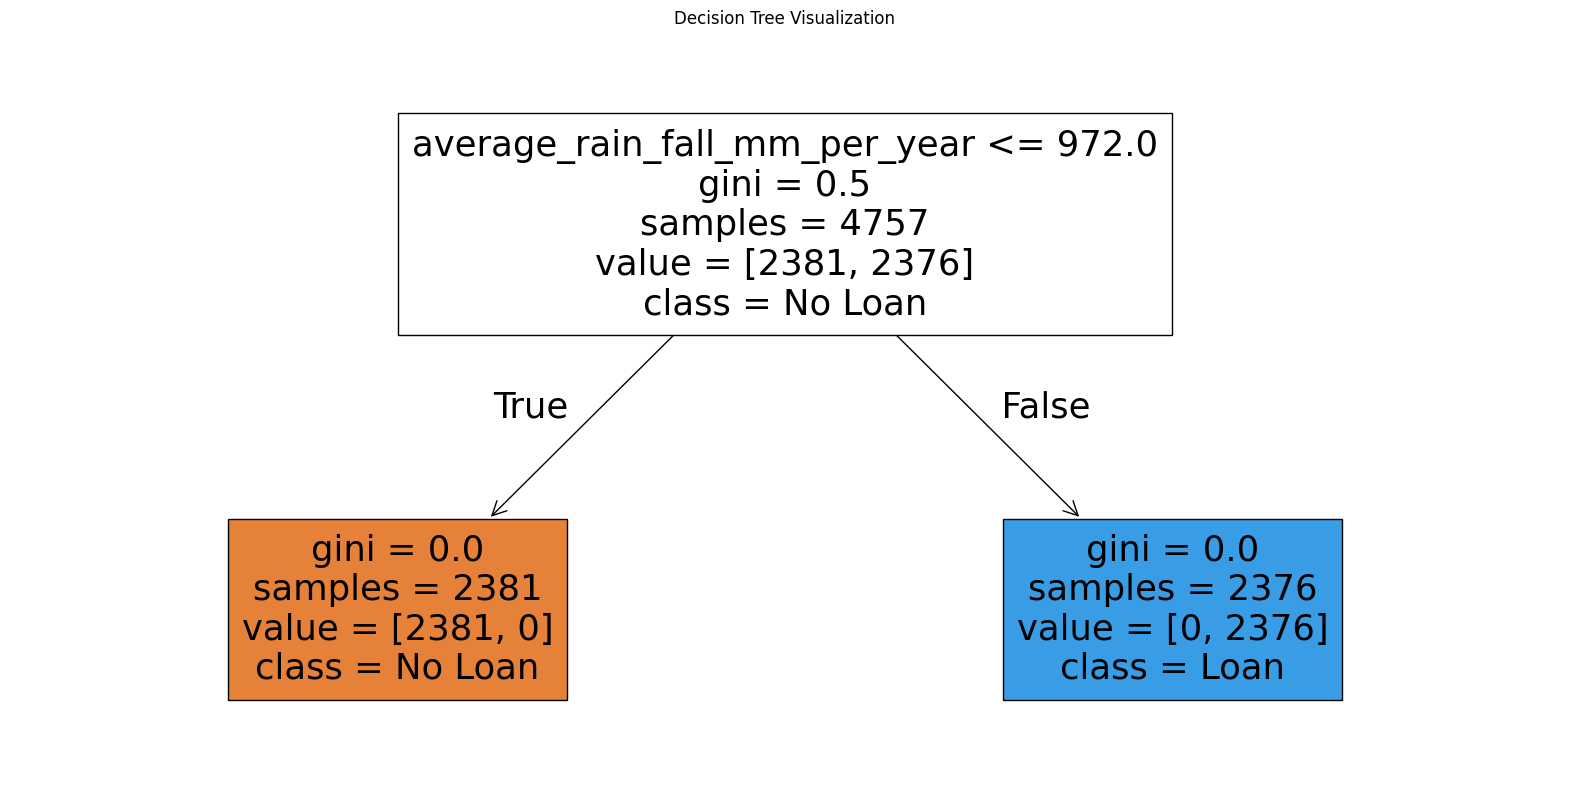

In [30]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Loan', 'Loan'],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

#Better Visualization (Graphviz — Recommended)


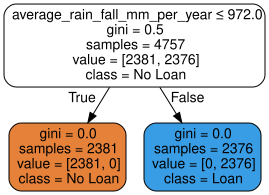

In [31]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X.columns,
    class_names=['No Loan', 'Loan'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

8. Overfitting Problem

⚠️ Overfitting
Decision Trees can: 👉 Memorize training data

Symptoms
Very high training accuracy
Low test accuracy
Solution
👉 Pruning / Limiting tree depth

#Control Overfitting


In [32]:
dt_model_limited = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt_model_limited.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

9. Feature Importance

In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
1,average_rain_fall_mm_per_year,1.0
0,Year,0.0


Plot Feature Importance

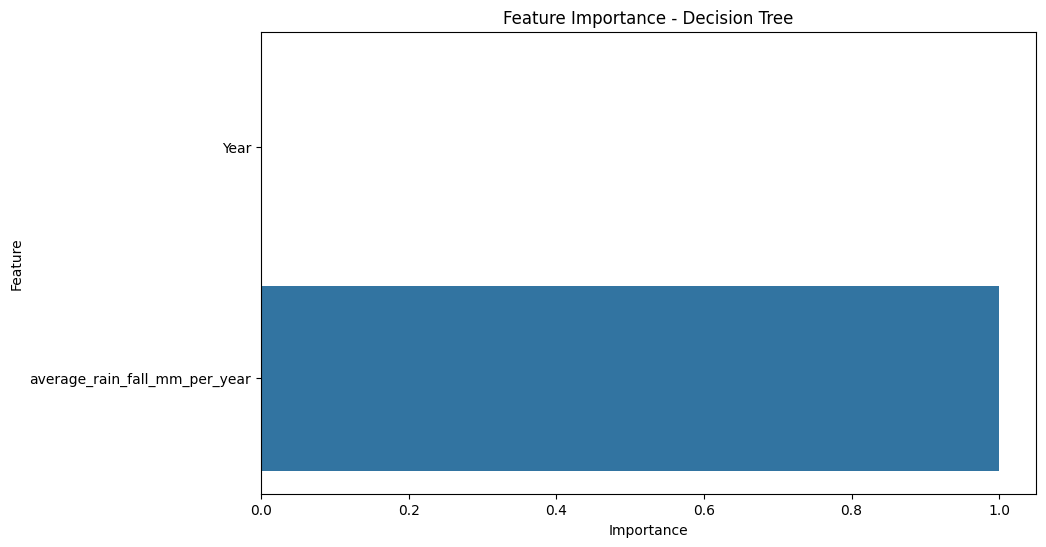

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.sort_values(by='Importance')
)

plt.title("Feature Importance - Decision Tree")
plt.show()

10. Decision Boundary (Using PCA)

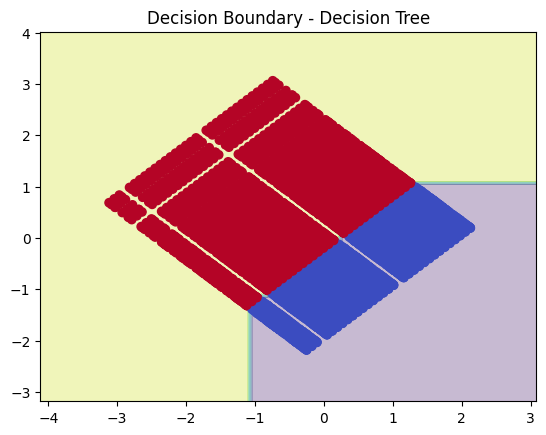

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dt_vis = DecisionTreeClassifier()
dt_vis.fit(X_pca, y)

# Meshgrid
import numpy as np

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = dt_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')
plt.title("Decision Boundary - Decision Tree")
plt.show()

11. Key Insights

✅ Decision Tree Summary
Advantages
✔ Easy to understand
✔ No need for scaling
✔ Handles non-linear data

Limitations
✖ Overfitting
✖ Unstable (small data change → different tree)

When to Use?
Interpretability needed
Rule-based systems
Non-linear relationships

| Feature / Aspect            | Logistic Regression 🧠 | Multivariate Logistic 🔁 | SVM ⚡ | Decision Tree 🌳 |
|----------------------------|----------------------|--------------------------|--------|------------------|
| Type                       | Linear Model         | Linear Model             | Linear + Non-linear | Non-linear |
| Input Features             | Single / Multiple    | Multiple                 | Multiple | Multiple |
| Output                     | Probability (0–1)    | Probability (0–1)        | Class label | Class label |
| Decision Boundary          | Linear               | Linear                   | Linear / Non-linear | Non-linear (hierarchical) |
| Interpretability           | High                 | High                     | Low     | Very High |
| Handles Non-linearity      | ❌ No                | ❌ No                    | ✅ Yes  | ✅ Yes |
| Feature Scaling Required   | ✅ Yes               | ✅ Yes                   | ✅ Yes  | ❌ No |
| Handles High Dimensions    | ⚠️ Moderate          | ⚠️ Moderate              | ✅ Excellent | ⚠️ Moderate |
| Overfitting Risk           | Low                  | Low                      | Medium  | High |
| Training Speed             | Fast                 | Fast                     | Slow (large data) | Fast |
| Hyperparameters            | Few                  | Few                      | Many (C, gamma, kernel) | Few (depth, split) |
| Best For                   | Simple problems      | Real-world baseline      | Complex boundaries | Rule-based decisions |
| Visualization              | Easy                 | Moderate (PCA needed)    | Hard (PCA needed) | Very Easy (tree) |
| Robust to Outliers         | ❌ No                | ❌ No                    | ⚠️ Moderate | ⚠️ Moderate |
| Probability Output         | ✅ Yes               | ✅ Yes                   | ⚠️ Limited (needs prob=True) | ❌ No (basic) |
| Real-world Usage           | Baseline model       | Strong baseline          | Advanced ML tasks | Business rules |

📌 When to Use What?
👉 Logistic Regression

When data is linear
Need interpretability
👉 Multivariate Logistic

Real-world baseline model
Multiple features involved
👉 SVM

Complex / non-linear data
High-dimensional datasets
👉 Decision Tree

Need explainable model
Rule-based decisions